# *FOR STANDARD DATA* ----------------------------  VGG16 + VGG 19

In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.layers import Input, Concatenate, Flatten
from tensorflow.keras.models import Model
from sklearn.neighbors import KNeighborsClassifier

# Define the directory where your dataset is located
dataset_dir = "D://minorPROJECT//Majorproject//training_dataset2"


In [2]:

# Initialize lists to store images and labels
images = []
labels = []

# Loop through each class label in the dataset directory
for class_label in os.listdir(dataset_dir):
    class_dir = os.path.join(dataset_dir, class_label)

    # Check if it's a directory
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            image_path = os.path.join(class_dir, filename)
            image = cv2.imread(image_path)

            # Resize and preprocess the image as needed
            image = cv2.resize(image, (224, 224))
            image = image / 255.0  # Normalize pixel values

            images.append(image)
            labels.append(class_label)

# Convert lists to NumPy arrays
train_images = np.array(images)
train_labels = np.array(labels)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

# Encode class labels into numerical values
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Define the input shape for the model
input_shape = (224, 224, 3)

# Define input layers
input_vgg16 = Input(shape=input_shape, name="input_vgg16")
input_vgg19 = Input(shape=input_shape, name="input_vgg19")

# Load and configure VGG16
vgg16_base = VGG16(weights='imagenet', include_top=False)
for layer in vgg16_base.layers:
    layer.trainable = False
vgg16 = Model(inputs=vgg16_base.input, outputs=vgg16_base.layers[-1].output)(input_vgg16)

# Load and configure VGG19
vgg19_base = VGG19(weights='imagenet', include_top=False)
for layer in vgg19_base.layers:
    layer.trainable = False
vgg19 = Model(inputs=vgg19_base.input, outputs=vgg19_base.layers[-1].output)(input_vgg19)

# Merge the features
merged_features = Concatenate()([vgg16, vgg19])

# Flatten the merged features
x = Flatten()(merged_features)

# Create a hybrid feature extraction model
feature_extraction_model = Model(inputs=[input_vgg16, input_vgg19], outputs=x)





In [3]:
from tensorflow.keras.models import Model, load_model

In [4]:
# Load the pre-trained model
model = load_model('my_model_standard1619.h5')

In [5]:
# Use the feature extraction model to process the test data
X_test_features = feature_extraction_model.predict([X_test, X_test])

22/22 [==============================] - 186s 8s/step


In [7]:
# Predict the output using the loaded model
predictions = model.predict(X_test_features)

22/22 [==============================] - 0s 11ms/step


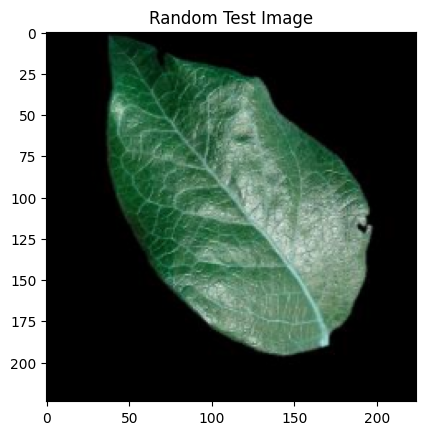

1/1 [==============================] - 0s 47ms/step
Predicted Label: Blueberry
Actual Label: Blueberry


In [21]:
import matplotlib.pyplot as plt

# Select a random index from the test set
n = np.random.randint(0, X_test.shape[0])

# Get the image at the selected index
img = X_test[n]

# Display the image
plt.imshow(img)
plt.title("Random Test Image")
plt.show()

# Prepare the image for prediction
input_img = np.expand_dims(img, axis=0)

# Use the feature extraction model to process the input image
input_img_features = feature_extraction_model.predict([input_img, input_img])

# Predict the output label using the pre-trained model
prediction = model.predict(input_img_features)

# Decode the predicted label
predicted_label = le.inverse_transform([np.argmax(prediction)])[0]

# Decode the actual label
actual_label = le.inverse_transform([y_test_encoded[n]])[0]

print("Predicted Label:", predicted_label)
print("Actual Label:", actual_label)


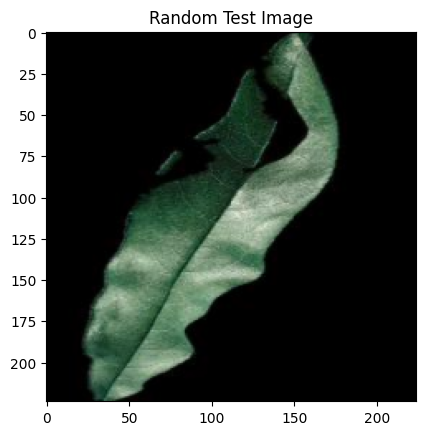

1/1 [==============================] - 0s 40ms/step
Predicted Label: Peach
Actual Label: Peach


In [23]:
import matplotlib.pyplot as plt

# Select a random index from the test set
n = np.random.randint(0, X_test.shape[0])

# Get the image at the selected index
img = X_test[n]

# Display the image
plt.imshow(img)
plt.title("Random Test Image")
plt.show()

# Prepare the image for prediction
input_img = np.expand_dims(img, axis=0)

# Use the feature extraction model to process the input image
input_img_features = feature_extraction_model.predict([input_img, input_img])

# Predict the output label using the pre-trained model
prediction = model.predict(input_img_features)

# Decode the predicted label
predicted_label = le.inverse_transform([np.argmax(prediction)])[0]

# Decode the actual label
actual_label = le.inverse_transform([y_test_encoded[n]])[0]

print("Predicted Label:", predicted_label)
print("Actual Label:", actual_label)


In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
from sklearn.manifold import TSNE

# Assuming you have already defined your feature_extraction_model and X_train
# Extract features from your model for visualization
X_train_features = feature_extraction_model.predict([X_train, X_train])

# Apply t-SNE to reduce dimensionality
tsne = TSNE(n_components=2, random_state=42)
X_train_features_tsne = tsne.fit_transform(X_train_features)


88/88 [==============================] - 785s 9s/step


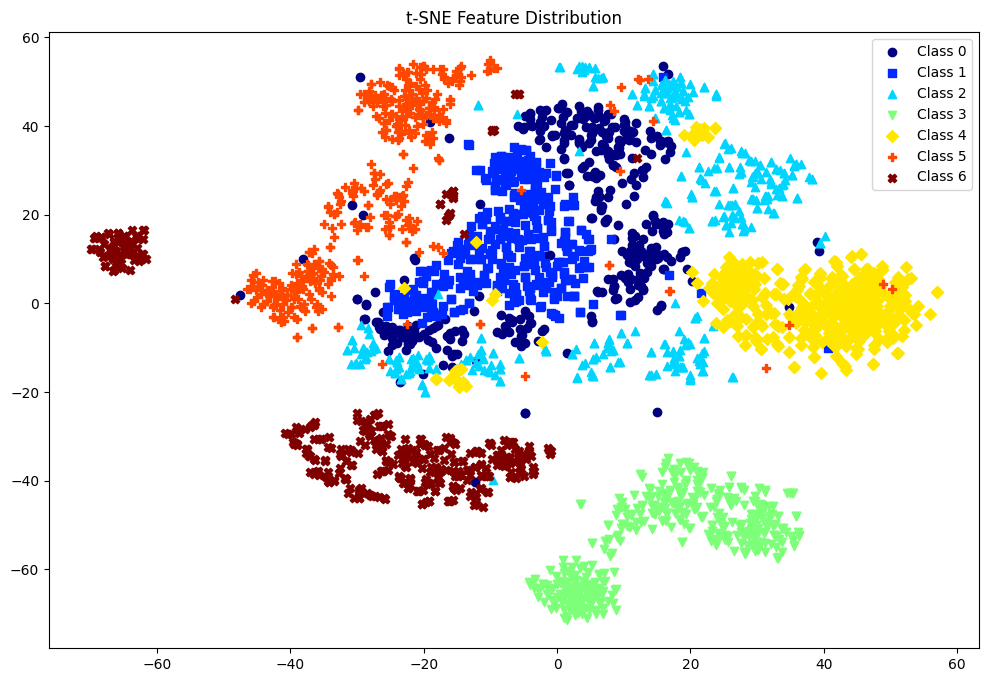

In [14]:
# Plot the feature distribution with colors and markers for classes
unique_labels = np.unique(y_train_encoded)
colors = plt.cm.jet(np.linspace(0, 1, len(unique_labels)))
markers = ['o', 's', '^', 'v', 'D', 'P', 'X']
plt.figure(figsize=(12, 8))
for i, label in enumerate(unique_labels):
    class_indices = np.where(y_train_encoded == label)[0]
    plt.scatter(X_train_features_tsne[class_indices, 0], X_train_features_tsne[class_indices, 1],
                color=colors[i], label=f'Class {label}', marker=markers[i])
plt.legend()
plt.title("t-SNE Feature Distribution")
plt.show()


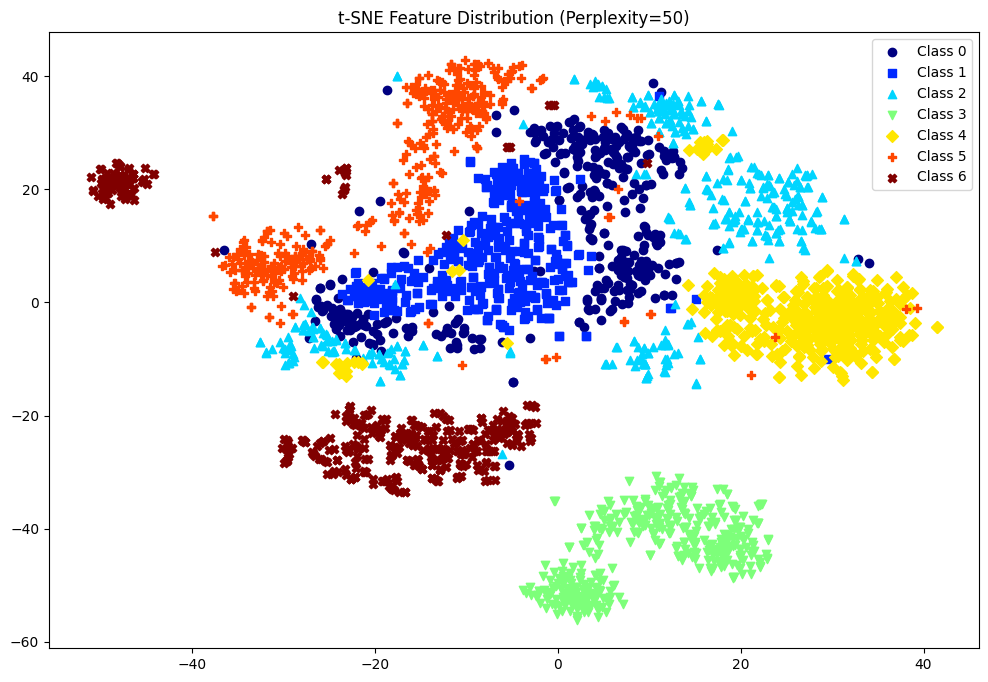

In [15]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have X_train_features_tsne, y_train_encoded already defined

# Define perplexity (experiment with different values)
perplexity = 50

# Initialize and fit t-SNE
tsne = TSNE(n_components=2, perplexity=perplexity)
X_train_features_tsne = tsne.fit_transform(X_train_features)

# Plot the feature distribution with colors and markers for classes
unique_labels = np.unique(y_train_encoded)
colors = plt.cm.jet(np.linspace(0, 1, len(unique_labels)))
markers = ['o', 's', '^', 'v', 'D', 'P', 'X']
plt.figure(figsize=(12, 8))
for i, label in enumerate(unique_labels):
    class_indices = np.where(y_train_encoded == label)[0]
    plt.scatter(X_train_features_tsne[class_indices, 0], X_train_features_tsne[class_indices, 1],
                color=colors[i], label=f'Class {label}', marker=markers[i])
plt.legend()
plt.title("t-SNE Feature Distribution (Perplexity={})".format(perplexity))
plt.show()


# *FOR REAL TIME DATA* ---------------------------- VGG16 + VGG 19

In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.layers import Input, Concatenate, Flatten
from tensorflow.keras.models import Model
# Define the directory where your dataset is located
dataset_dir = "D://Newdataset/"

In [2]:




# Initialize lists to store images and labels
images = []
labels = []

# Loop through each class label in the dataset directory
for class_label in os.listdir(dataset_dir):
    class_dir = os.path.join(dataset_dir, class_label)

    # Check if it's a directory
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            image_path = os.path.join(class_dir, filename)
            image = cv2.imread(image_path)

            # Resize and preprocess the image as needed
            image = cv2.resize(image, (224, 224))
            image = image / 255.0  # Normalize pixel values

            images.append(image)
            labels.append(class_label)

# Convert lists to NumPy arrays
train_images = np.array(images)
train_labels = np.array(labels)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

# Encode class labels into numerical values
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Define the input shape for the model
input_shape = (224, 224, 3)

# Define input layers
input_vgg16 = Input(shape=input_shape, name="input_vgg16")
input_vgg19 = Input(shape=input_shape, name="input_vgg19")

# Load and configure VGG16
vgg16_base = VGG16(weights='imagenet', include_top=False)
for layer in vgg16_base.layers:
    layer.trainable = False
vgg16 = Model(inputs=vgg16_base.input, outputs=vgg16_base.layers[-1].output)(input_vgg16)

# Load and configure VGG19
vgg19_base = VGG19(weights='imagenet', include_top=False)
for layer in vgg19_base.layers:
    layer.trainable = False
vgg19 = Model(inputs=vgg19_base.input, outputs=vgg19_base.layers[-1].output)(input_vgg19)

# Merge the features
merged_features = Concatenate()([vgg16, vgg19])

# Flatten the merged features
x = Flatten()(merged_features)

# Create a hybrid feature extraction model
feature_extraction_model = Model(inputs=[input_vgg16, input_vgg19], outputs=x)

In [3]:
from tensorflow.keras.models import Model, load_model

In [4]:
model = load_model('hybrid_model_vgg1619_realtimedataset.h5')

In [5]:
# Use the feature extraction model to process the test data
X_test_features = feature_extraction_model.predict([X_test, X_test])

25/25 [==============================] - 213s 9s/step


In [7]:
# Predict the output using the loaded model
predictions = model.predict(X_test_features)

25/25 [==============================] - 0s 13ms/step


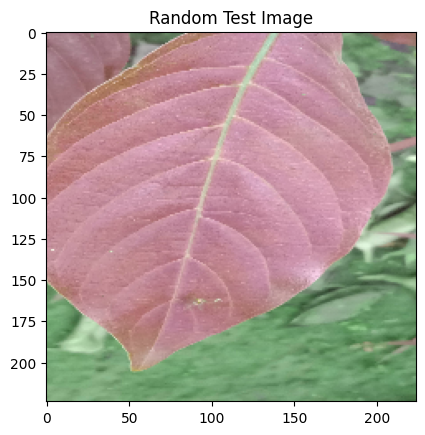

1/1 [==============================] - 0s 80ms/step
Predicted Label: Helimia
Actual Label: Helimia


In [6]:
import matplotlib.pyplot as plt

# Select a random index from the test set
n = np.random.randint(0, X_test.shape[0])

# Get the image at the selected index
img = X_test[n]

# Display the image
plt.imshow(img)
plt.title("Random Test Image")
plt.show()

# Prepare the image for prediction
input_img = np.expand_dims(img, axis=0)

# Use the feature extraction model to process the input image
input_img_features = feature_extraction_model.predict([input_img, input_img])

# Predict the output label using the pre-trained model
prediction = model.predict(input_img_features)

# Decode the predicted label
predicted_label = le.inverse_transform([np.argmax(prediction)])[0]

# Decode the actual label
actual_label = le.inverse_transform([y_test_encoded[n]])[0]

print("Predicted Label:", predicted_label)
print("Actual Label:", actual_label)


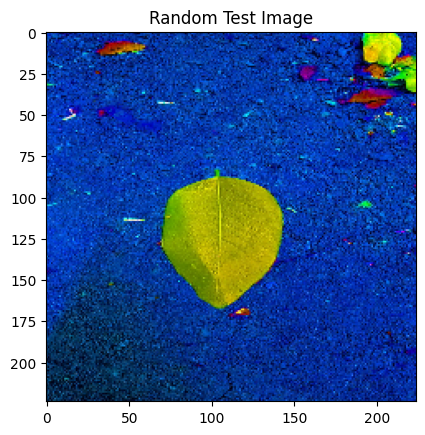

1/1 [==============================] - 0s 55ms/step
Predicted Label: final aragodha
Actual Label: final aragodha


In [15]:
import matplotlib.pyplot as plt

# Select a random index from the test set
n = np.random.randint(0, X_test.shape[0])

# Get the image at the selected index
img = X_test[n]

# Display the image
plt.imshow(img)
plt.title("Random Test Image")
plt.show()

# Prepare the image for prediction
input_img = np.expand_dims(img, axis=0)

# Use the feature extraction model to process the input image
input_img_features = feature_extraction_model.predict([input_img, input_img])

# Predict the output label using the pre-trained model
prediction = model.predict(input_img_features)

# Decode the predicted label
predicted_label = le.inverse_transform([np.argmax(prediction)])[0]

# Decode the actual label
actual_label = le.inverse_transform([y_test_encoded[n]])[0]

print("Predicted Label:", predicted_label)
print("Actual Label:", actual_label)


# *FOR STANDARD DATASET* -------- vgg16+mobilenet 

In [6]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate
from keras.models import Model
from keras.applications.imagenet_utils import preprocess_input
from keras.applications.mobilenet import MobileNet
from keras.applications import VGG16, MobileNet

In [7]:
# Initialize lists to store images and labels
images = []
labels = []

In [8]:
# Define the directory where your dataset is located
dataset_dir = "D://minorPROJECT//Majorproject//training_dataset2"

In [9]:
# Loop through each class label in the dataset directory
for class_label in os.listdir(dataset_dir):
    class_dir = os.path.join(dataset_dir, class_label)

    # Check if it's a directory
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            image_path = os.path.join(class_dir, filename)
            image = cv2.imread(image_path)

            # Resize and preprocess the image as needed
            image = cv2.resize(image, (224, 224))
            image = image / 255.0  # Normalize pixel values

            images.append(image)
            labels.append(class_label)

# Convert lists to NumPy arrays
train_images = np.array(images)
train_labels = np.array(labels)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

# Encode class labels into numerical values
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Define the input shape for the model
input_shape = (224, 224, 3)

# Define input layers
input_vgg16 = Input(shape=input_shape, name="input_vgg16")
input_mobilenet = Input(shape=input_shape, name="input_mobilenet")

# Load and configure VGG16
vgg16_base = VGG16(weights='imagenet', include_top=False)
for layer in vgg16_base.layers:
    layer.trainable = False
vgg16 = vgg16_base(input_vgg16)

# Load and configure MobileNet
mobilenet_base = MobileNet(weights='imagenet', include_top=False)
for layer in mobilenet_base.layers:
    layer.trainable = False
mobilenet = mobilenet_base(input_mobilenet)

# Merge the features
merged_features = Concatenate()([vgg16, mobilenet])

# Flatten the merged features
x = Flatten()(merged_features)

# Create a hybrid feature extraction model
feature_extraction_model = Model(inputs=[input_vgg16, input_mobilenet], outputs=x)


In [11]:
from keras.models import Model, load_model

In [12]:
# Load the pre-trained hybrid model
model = load_model('modelstandardvgg19mobilenet.h5')


In [14]:
# Use the feature extraction model to process the test data
X_test_features = feature_extraction_model.predict([X_test, X_test])

22/22 [==============================] - 91s 4s/step


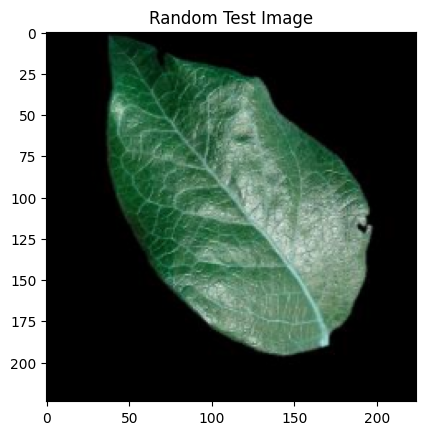

1/1 [==============================] - 0s 111ms/step
Predicted Label: Blueberry
Actual Label: Blueberry


In [16]:
import matplotlib.pyplot as plt
# Select a random index from the test set
n = np.random.randint(0, X_test.shape[0])

# Get the image at the selected index
img = X_test[n]

# Display the image
plt.imshow(img)
plt.title("Random Test Image")
plt.show()

# Prepare the image for prediction
input_img = np.expand_dims(img, axis=0)

# Use the feature extraction model to process the input image
input_img_features = feature_extraction_model.predict([input_img, input_img])

# Predict the output label using the pre-trained model
prediction = model.predict(input_img_features)

# Decode the predicted label
predicted_label = le.inverse_transform([np.argmax(prediction)])[0]

# Decode the actual label
actual_label = le.inverse_transform([y_test_encoded[n]])[0]

print("Predicted Label:", predicted_label)
print("Actual Label:", actual_label)

# *FOR REALTIME  DATASET* -------- vgg16+mobilenet 

In [11]:

# Define the directory where your dataset is located
dataset_dir = "D://Newdataset/"

# Initialize lists to store images and labels
images = []
labels = []

# Loop through each class label in the dataset directory
for class_label in os.listdir(dataset_dir):
    class_dir = os.path.join(dataset_dir, class_label)

    # Check if it's a directory
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            image_path = os.path.join(class_dir, filename)
            image = cv2.imread(image_path)

            # Resize and preprocess the image as needed
            image = cv2.resize(image, (224, 224))
            image = image / 255.0  # Normalize pixel values

            images.append(image)
            labels.append(class_label)

# Convert lists to NumPy arrays
train_images = np.array(images)
train_labels = np.array(labels)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

# Encode class labels into numerical values
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Define the input shape for the model
input_shape = (224, 224, 3)

# Define input layers
input_vgg = Input(shape=input_shape, name="input_vgg")
input_mobilenet = Input(shape=input_shape, name="input_mobilenet")

# Load and configure VGG16
vgg16_base = VGG16(weights='imagenet', include_top=False)
for layer in vgg16_base.layers:
    layer.trainable = False
vgg16 = Model(inputs=vgg16_base.input, outputs=vgg16_base.layers[-1].output)(input_vgg)

# Load and configure MobileNet
mobilenet_base = MobileNet(weights='imagenet', include_top=False)
for layer in mobilenet_base.layers:
    layer.trainable = False
mobilenet = Model(inputs=mobilenet_base.input, outputs=mobilenet_base.layers[-1].output)(input_mobilenet)

# Merge the features
merged_features = Concatenate()([vgg16, mobilenet])

# Flatten the merged features
x = Flatten()(merged_features)

# Create a hybrid feature extraction model
feature_extraction_model = Model(inputs=[input_vgg, input_mobilenet], outputs=x)

NameError: name 'Input' is not defined

In [19]:
from keras.models import Model, load_model
# Load the pre-trained hybrid model
model = load_model('my_model.h5')

In [20]:
# Use the feature extraction model to process the test data
X_test_features = feature_extraction_model.predict([X_test, X_test])

25/25 [==============================] - 109s 4s/step


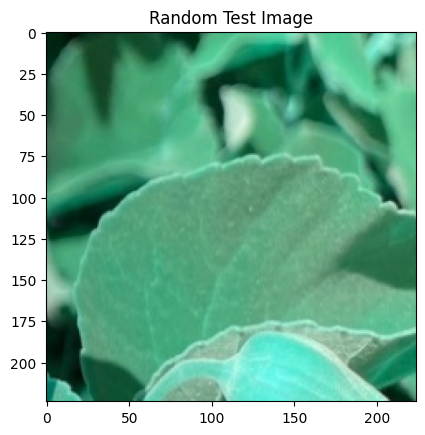

1/1 [==============================] - 0s 77ms/step
Predicted Label: abutilon
Actual Label: abutilon


In [21]:
import matplotlib.pyplot as plt
# Select a random index from the test set
n = np.random.randint(0, X_test.shape[0])

# Get the image at the selected index
img = X_test[n]

# Display the image
plt.imshow(img)
plt.title("Random Test Image")
plt.show()

# Prepare the image for prediction
input_img = np.expand_dims(img, axis=0)

# Use the feature extraction model to process the input image
input_img_features = feature_extraction_model.predict([input_img, input_img])

# Predict the output label using the pre-trained model
prediction = model.predict(input_img_features)

# Decode the predicted label
predicted_label = le.inverse_transform([np.argmax(prediction)])[0]

# Decode the actual label
actual_label = le.inverse_transform([y_test_encoded[n]])[0]

print("Predicted Label:", predicted_label)
print("Actual Label:", actual_label)

# *FOR STANDADR DATASET* --------- inceptionv3+mobilenet

22/22 [==============================] - 36s 2s/step


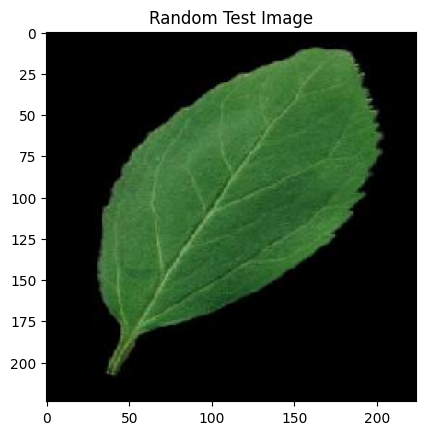

1/1 [==============================] - 0s 82ms/step
Predicted Label: Apple
Actual Label: Cherry


In [14]:
from keras.models import load_model
from keras.preprocessing.image import load_img, img_to_array
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os
import numpy as np
from keras.applications import InceptionV3
import matplotlib.pyplot as plt

# Define your dataset directory
dataset_dir = "D://minorPROJECT//Majorproject//training_dataset2"

# Load the dataset
X = []
y = []
for class_name in os.listdir(dataset_dir):
    class_dir = os.path.join(dataset_dir, class_name)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        img = load_img(img_path, target_size=(224, 224))
        img = img_to_array(img)
        X.append(img)
        y.append(class_name)
X = np.array(X)
y = np.array(y)

# Normalize the images
X = X / 255.0

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an instance of the InceptionV3 model
inception_Model = InceptionV3(include_top=False, pooling='avg')

# Extract features using the InceptionV3 model
inception_features_train = inception_Model.predict(X_train)
inception_features_test = inception_Model.predict(X_test)

# Standardize the features
scaler = preprocessing.StandardScaler().fit(inception_features_train)
inception_features_train = scaler.transform(inception_features_train)
inception_features_test = scaler.transform(inception_features_test)

# Concatenate the features
combined_features_train = np.concatenate((inception_features_train, inception_features_train), axis=1)
combined_features_test = np.concatenate((inception_features_test, inception_features_test), axis=1)

# Encode class labels into numerical values
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Load the saved model
model = load_model('modelmobilenet+inceptionv3_standarddataset.h5')

# Select a random index from the test set
n = np.random.randint(0, X_test.shape[0])

# Get the image at the selected index
img = X_test[n]

# Display the image
plt.imshow(img)
plt.title("Random Test Image")
plt.show()

# Prepare the image for prediction
input_img = np.expand_dims(img, axis=0)

# Use the feature extraction models to process the input image
inception_features = inception_Model.predict(input_img)

# Normalize the feature vectors
# Reshape the input_img_features to match the expected shape
input_img_features = input_img_features[:, :3072]

# Predict the output label using the loaded model
prediction = model.predict(input_img_features)

# Decode the predicted label
predicted_label = le.inverse_transform([np.argmax(prediction)])[0]

# Decode the actual label
actual_label = le.inverse_transform([y_test_encoded[n]])[0]

print("Predicted Label:", predicted_label)
print("Actual Label:", actual_label)

# *FOR REALTIME DATASET* --------- inceptionv3+mobilenet